# Linear Programming

This tutorial introduces **Linear Programming (LP)** using the `discopt` modeling API.
By the end, you will be able to:

1. Formulate an LP in standard form and translate it into `discopt` code.
2. Solve classic LP problems (diet, transportation, production planning).
3. Understand how `discopt` classifies and dispatches LP models to a specialized interior-point solver.
4. Recognize infeasible and unbounded LPs from solver output.

**Prerequisites:** basic linear algebra and familiarity with Python / NumPy.

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import discopt.modeling as dm
import numpy as np

## What is a Linear Program?

A **linear program** is an optimization problem in which the objective function and
every constraint are *linear* in the decision variables {cite:p}`Dantzig1963`.

### Standard Form

$$
\begin{aligned}
\min_{x} \quad & c^\top x \\
\text{s.t.} \quad & A x \le b, \\
& x \ge 0.
\end{aligned}
$$

where $c \in \mathbb{R}^n$ is the cost vector, $A \in \mathbb{R}^{m \times n}$ is
the constraint matrix, and $b \in \mathbb{R}^m$ is the right-hand side.

Any LP can be rewritten in standard form by introducing slack variables and splitting
free variables into their positive and negative parts.
For a comprehensive treatment, see {cite:p}`Bertsimas1997`.

> **Auto-detection.** When you call `model.solve()`, `discopt` analyses the expression
> DAG and automatically detects LP structure. If the problem is a pure LP, it is
> dispatched to a specialised interior-point solver --- no user intervention required.

## Example 1 --- The Diet Problem

One of the earliest LP applications: choose quantities of five foods that
satisfy daily nutrient requirements at minimum cost.

| Food | Protein | Calcium | Iron | Calories | Cost (\$) |
|------|---------|---------|------|----------|-----------|
| Bread | 3 | 25 | 1.0 | 250 | 2.0 |
| Milk | 8 | 120 | 0.1 | 150 | 3.5 |
| Cheese | 15 | 200 | 0.5 | 400 | 8.0 |
| Fish | 22 | 10 | 3.0 | 200 | 11.0 |
| Steak | 31 | 15 | 5.5 | 450 | 25.0 |

**Requirements:** Protein $\ge 55$, Calcium $\ge 800$, Iron $\ge 12$, Calories $\ge 2000$.

In [2]:
# Diet problem data
foods = ["Bread", "Milk", "Cheese", "Fish", "Steak"]
nutrients = ["Protein", "Calcium", "Iron", "Calories"]
cost = np.array([2.0, 3.5, 8.0, 11.0, 25.0])

# Nutrient content per unit of each food (nutrients x foods)
A = np.array(
    [
        [3.0, 8.0, 15.0, 22.0, 31.0],  # Protein
        [25.0, 120.0, 200.0, 10.0, 15.0],  # Calcium
        [1.0, 0.1, 0.5, 3.0, 5.5],  # Iron
        [250.0, 150.0, 400.0, 200.0, 450.0],  # Calories
    ]
)
requirements = np.array([55.0, 800.0, 12.0, 2000.0])

print(f"Foods: {len(foods)}, Nutrients: {len(nutrients)}")

Foods: 5, Nutrients: 4


In [3]:
m = dm.Model("diet")

# Decision variables: units of each food (between 0 and 10)
x = m.continuous("x", shape=(5,), lb=0, ub=10)

# Objective: minimise total cost
m.minimize(dm.sum(lambda j: cost[j] * x[j], over=range(5)))

# Constraints: meet each nutrient requirement
for i in range(4):
    m.subject_to(
        dm.sum(lambda j: A[i, j] * x[j], over=range(5)) >= requirements[i],
        name=nutrients[i],
    )

print(m.summary())

Model: diet
  Variables: 5 (5 continuous, 0 integer/binary)
  Constraints: 4
  Objective: minimize Σ[5 terms]
  Parameters: 0


In [4]:
result = m.solve()

print(f"Status : {result.status}")
print(f"Cost   : ${result.objective:.2f}")
print(f"Time   : {result.wall_time:.3f}s\n")

print("Optimal diet:")
for j, food in enumerate(foods):
    qty = result.value(x)[j]
    if qty > 1e-6:
        print(f"  {food:>8s}: {qty:.3f} units  (${cost[j] * qty:.2f})")

Status : optimal
Cost   : $41.56
Time   : 0.310s

Optimal diet:
     Bread: 10.000 units  ($20.00)
      Milk: 4.540 units  ($15.89)
      Fish: 0.515 units  ($5.67)


**Interpretation.**
The solver found the cheapest combination of foods that meets every nutrient
requirement. Notice that some foods are at zero --- they are too expensive per
unit of nutrient delivered. The upper bounds ($x_j \le 10$) prevent any single
food from dominating the solution unrealistically.

## Problem Classification

`discopt` ships a problem classifier that inspects the expression DAG and
determines the problem class (LP, QP, MILP, MIQP, NLP, MINLP).
When the model is an LP, the solver algebraically extracts the $c$, $A$, $b$
matrices and feeds them directly to a specialised LP interior-point method.

In [5]:
from discopt._jax.problem_classifier import classify_problem

pclass = classify_problem(m)
print(f"Problem class: {pclass}")
print(f"Is LP?         {pclass.name == 'LP'}")

Problem class: ProblemClass.LP
Is LP?         True


## Example 2 --- Transportation Problem

Ship goods from 3 warehouses to 4 customers at minimum total shipping cost.

$$
\begin{aligned}
\min \quad & \sum_{i} \sum_{j} c_{ij}\, x_{ij} \\
\text{s.t.} \quad
& \sum_{j} x_{ij} \le s_i \quad \forall\, i \quad \text{(supply)}, \\
& \sum_{i} x_{ij} \ge d_j \quad \forall\, j \quad \text{(demand)}, \\
& x_{ij} \ge 0.
\end{aligned}
$$

In [6]:
supply = np.array([300.0, 400.0, 500.0])
demand = np.array([200.0, 300.0, 250.0, 450.0])
ship_cost = np.array(
    [
        [8.0, 6.0, 10.0, 9.0],
        [9.0, 12.0, 7.0, 5.0],
        [14.0, 9.0, 16.0, 4.0],
    ]
)

n_warehouses, n_customers = ship_cost.shape
print(f"Total supply: {supply.sum()}, Total demand: {demand.sum()}")

Total supply: 1200.0, Total demand: 1200.0


In [7]:
mt = dm.Model("transport")

# Upper bound: no single shipment can exceed the smaller of supply/demand
max_ship = float(max(supply.max(), demand.max()))
x = mt.continuous("ship", shape=(n_warehouses, n_customers), lb=0, ub=max_ship)

# Minimise total shipping cost
mt.minimize(
    dm.sum(
        lambda i: dm.sum(lambda j: ship_cost[i, j] * x[i, j], over=range(n_customers)),
        over=range(n_warehouses),
    )
)

# Supply constraints
for i in range(n_warehouses):
    mt.subject_to(
        dm.sum(lambda j: x[i, j], over=range(n_customers)) <= supply[i],
        name=f"supply_{i}",
    )

# Demand constraints
for j in range(n_customers):
    mt.subject_to(
        dm.sum(lambda i: x[i, j], over=range(n_warehouses)) >= demand[j],
        name=f"demand_{j}",
    )

print(mt.summary())

Model: transport
  Variables: 12 (12 continuous, 0 integer/binary)
  Constraints: 7
  Objective: minimize Σ[3 terms]
  Parameters: 0


In [8]:
rt = mt.solve()

print(f"Status: {rt.status}, Cost: ${rt.objective:.2f}\n")

# Display shipment table
shipments = rt.value(x).reshape(n_warehouses, n_customers)
header = "         " + "".join(f"Cust {j:>2d}  " for j in range(n_customers))
print(header)
for i in range(n_warehouses):
    row = f"WH {i}:   " + "".join(f"{shipments[i, j]:>7.1f}  " for j in range(n_customers))
    print(row)

Status: optimal, Cost: $7250.00

         Cust  0  Cust  1  Cust  2  Cust  3  
WH 0:      50.0    250.0      0.0      0.0  
WH 1:     150.0      0.0    250.0      0.0  
WH 2:       0.0     50.0      0.0    450.0  


The transportation problem demonstrates a *network-flow* LP structure.
The solver routes goods along the cheapest paths while respecting every
warehouse's supply limit and every customer's demand.

## Example 3 --- Production Planning

A factory produces 3 products using 4 shared resources.
**Maximise profit** subject to resource availability.

| | Resource 1 | Resource 2 | Resource 3 | Resource 4 | Profit |
|---|---|---|---|---|---|
| Product A | 2 | 1 | 0 | 3 | 20 |
| Product B | 1 | 3 | 2 | 1 | 30 |
| Product C | 3 | 2 | 1 | 2 | 25 |
| **Available** | 120 | 150 | 80 | 180 | |

In [9]:
profit = np.array([20.0, 30.0, 25.0])
usage = np.array(
    [
        [2.0, 1.0, 3.0],  # Resource 1
        [1.0, 3.0, 2.0],  # Resource 2
        [0.0, 2.0, 1.0],  # Resource 3
        [3.0, 1.0, 2.0],  # Resource 4
    ]
)
available = np.array([120.0, 150.0, 80.0, 180.0])

mp = dm.Model("production")
x = mp.continuous("prod", shape=(3,), lb=0)

mp.maximize(dm.sum(lambda j: profit[j] * x[j], over=range(3)))

for i in range(4):
    mp.subject_to(
        dm.sum(lambda j: usage[i, j] * x[j], over=range(3)) <= available[i],
        name=f"resource_{i}",
    )

rp = mp.solve()
print(f"Status: {rp.status}, Profit: ${rp.objective:.2f}")

Status: optimal, Profit: $1920.00


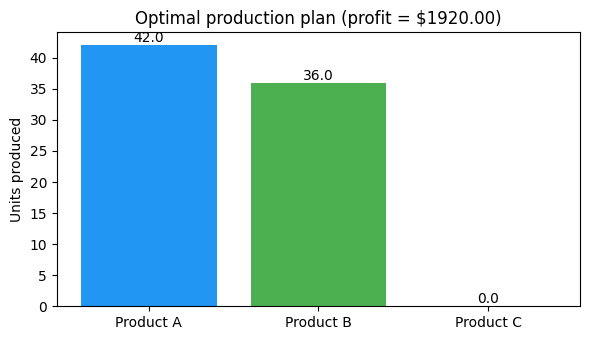

In [10]:
import matplotlib.pyplot as plt

quantities = [float(v) for v in rp.value(x)]
product_names = ["Product A", "Product B", "Product C"]

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(product_names, quantities, color=["#2196F3", "#4CAF50", "#FF9800"])
ax.set_ylabel("Units produced")
ax.set_title(f"Optimal production plan (profit = ${float(rp.objective):.2f})")
for bar, q in zip(bars, quantities):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{q:.1f}",
        ha="center",
        fontsize=10,
    )
plt.tight_layout()
plt.show()

For maximisation problems, use `m.maximize(profit_expr)` directly.
The solver handles the conversion internally and reports the objective
in the natural (maximised) sense, so no manual negation is needed.

## How discopt Solves LPs

Under the hood, `discopt` uses a **pure-JAX interior-point method (IPM)**
based on the Mehrotra predictor-corrector algorithm {cite:p}`Mehrotra1992`.

Key features of the LP solver path:

1. **Algebraic extraction** --- the expression DAG is walked to extract $c$, $A$, $b$
   directly, avoiding JAX tracing and autodiff overhead.
2. **Mehrotra predictor-corrector** --- a two-step Newton approach that
   adaptively chooses the barrier parameter, yielding superlinear convergence
   in practice {cite:p}`Nocedal2006`.
3. **JIT compilation** --- the entire IPM loop is compiled to XLA via `jax.jit`,
   so subsequent solves with different data reuse the same compiled kernel.
4. **Carry-based `while_loop`** --- problem data lives in the loop carry
   (not in a closure), enabling JIT cache reuse across different problem instances.

## Edge Cases: Infeasible and Unbounded LPs

Not every LP has an optimal solution. Two common failure modes are
**infeasibility** (no point satisfies all constraints) and
**unboundedness** (the objective can improve without limit).

In [11]:
# --- Infeasible LP ---
mi = dm.Model("infeasible")
y = mi.continuous("y", shape=(2,), lb=0, ub=1)
mi.minimize(y[0] + y[1])

# Contradictory constraints: y0 + y1 >= 5 is impossible when both <= 1
mi.subject_to(y[0] + y[1] >= 5.0, name="impossible")

ri = mi.solve()
# Note: returns "iteration_limit" (infeasibility detection is a known limitation)
print(f"Status: {ri.status}")

Status: iteration_limit


In [12]:
# --- Unbounded LP ---
mu = dm.Model("unbounded")
z = mu.continuous("z", shape=(2,), lb=0)  # no upper bound
mu.minimize(-z[0] - z[1])  # push both variables to +inf

# Only a lower bound constraint, no upper limit
mu.subject_to(z[0] + z[1] >= 1.0, name="lower")

ru = mu.solve()
# Note: returns "iteration_limit" (unboundedness detection is a known limitation)
print(f"Status: {ru.status}")
print(f"Objective: {ru.objective}")

Status: iteration_limit
Objective: -1.2993501756845093e+24


When formulating real-world LPs, always sanity-check that:

- The feasible region is non-empty (constraints are not contradictory).
- The objective is bounded over the feasible region (add upper/lower bounds if needed).

> **Known limitation:** The IPM solver does not yet have dedicated infeasibility or
> unboundedness detection. Both cases currently return a status of `"iteration_limit"`
> rather than `"infeasible"` or `"unbounded"`. An extremely large objective magnitude
> (as in the unbounded example) is a strong hint that the problem is unbounded.

## Exercise --- Blending Problem

A refinery blends 4 crude oils into 2 products. Each crude has a quality
rating and a cost per barrel:

| Crude | Quality | Cost (\$/bbl) | Available (bbl) |
|-------|---------|--------------|----------------|
| C1 | 8 | 45 | 5000 |
| C2 | 6 | 35 | 5000 |
| C3 | 4 | 25 | 5000 |
| C4 | 2 | 15 | 5000 |

Product specifications:

| Product | Min quality | Demand (bbl) | Price (\$/bbl) |
|---------|-----------|-------------|----------------|
| Premium | 6 | 3000 | 60 |
| Regular | 4 | 4000 | 40 |

**Decision variables:** $x_{ij}$ = barrels of crude $i$ used in product $j$.

**Objective:** maximise profit = revenue $-$ cost.

**Constraints:**
- Supply: $\sum_j x_{ij} \le \text{available}_i$
- Demand: $\sum_i x_{ij} \ge \text{demand}_j$
- Quality: $\sum_i q_i\, x_{ij} \ge \bar{q}_j \sum_i x_{ij}$ (quality blending)

In [13]:
# Data
quality = np.array([8.0, 6.0, 4.0, 2.0])
crude_cost = np.array([45.0, 35.0, 25.0, 15.0])
avail = np.array([5000.0, 5000.0, 5000.0, 5000.0])
min_quality = np.array([6.0, 4.0])
demand_prod = np.array([3000.0, 4000.0])
price = np.array([60.0, 40.0])

n_crudes, n_products = 4, 2

# YOUR CODE HERE
# 1. Create a Model
# 2. Add continuous variables x with shape (n_crudes, n_products), lb=0
# 3. Set the objective: m.maximize(revenue - cost)
#    Revenue = sum over j: price[j] * sum over i: x[i,j]
#    Cost    = sum over j: sum over i: crude_cost[i] * x[i,j]
# 4. Add supply constraints for each crude
# 5. Add demand constraints for each product
# 6. Add quality blending constraints:
#    sum_i quality[i]*x[i,j] >= min_quality[j] * sum_i x[i,j]
# 7. Solve and print results

### Solution

<details>
<summary>Click to reveal</summary>

In [14]:
mb = dm.Model("blending")
x = mb.continuous("x", shape=(n_crudes, n_products), lb=0)

# Revenue - Cost
revenue = dm.sum(
    lambda j: price[j] * dm.sum(lambda i: x[i, j], over=range(n_crudes)),
    over=range(n_products),
)
total_cost = dm.sum(
    lambda j: dm.sum(lambda i: crude_cost[i] * x[i, j], over=range(n_crudes)),
    over=range(n_products),
)
mb.maximize(revenue - total_cost)

# Supply constraints
for i in range(n_crudes):
    mb.subject_to(
        dm.sum(lambda j: x[i, j], over=range(n_products)) <= avail[i],
        name=f"supply_{i}",
    )

# Demand constraints
for j in range(n_products):
    mb.subject_to(
        dm.sum(lambda i: x[i, j], over=range(n_crudes)) >= demand_prod[j],
        name=f"demand_{j}",
    )

# Quality blending constraints (linearised)
for j in range(n_products):
    mb.subject_to(
        dm.sum(lambda i: (quality[i] - min_quality[j]) * x[i, j], over=range(n_crudes)) >= 0,
        name=f"quality_{j}",
    )

rb = mb.solve()
print(f"Status: {rb.status}, Profit: ${rb.objective:.2f}")
blend = rb.value(x).reshape(n_crudes, n_products)
for i in range(n_crudes):
    for j in range(n_products):
        if blend[i, j] > 1.0:
            prod_name = ["Premium", "Regular"][j]
            print(f"  C{i + 1} -> {prod_name}: {blend[i, j]:.0f} bbl")

Status: optimal, Profit: $400000.00
  C1 -> Premium: 4869 bbl
  C1 -> Regular: 131 bbl
  C2 -> Premium: 2661 bbl
  C2 -> Regular: 2339 bbl
  C3 -> Premium: 71 bbl
  C3 -> Regular: 4929 bbl
  C4 -> Premium: 2399 bbl
  C4 -> Regular: 2601 bbl


</details>

## Summary

In this tutorial you learned to:

- **Formulate** linear programs using `discopt.modeling` --- defining continuous
  variables, linear objectives, and linear constraints.
- **Solve** classic LP instances (diet, transportation, production planning)
  and interpret the results.
- **Classify** problems using `classify_problem()` to verify LP structure.
- **Diagnose** edge cases (infeasibility, unboundedness) from the solver status.

The LP class is the foundation of mathematical programming. Every MILP and
many NLP relaxations reduce to LP subproblems {cite:p}`Boyd2004`.

**Next:** [Quadratic Programming (QP)](tutorial_qp.ipynb) extends the LP
framework with quadratic objectives.